In [ ]:
import os
import random
import numpy as np
import scipy.io
import time
import math
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def set_deterministic_mode(seed=1234):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    random.seed(seed)
    np.random.seed(seed)
set_deterministic_mode(1234)

import tensorflow as tf
from tensorflow.keras import layers, initializers, optimizers
from tensorflow.keras.layers import Layer, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform, Zeros

tf.random.set_seed(1234)

tf.compat.v1.set_random_seed(1234)

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

niter2 = 50001
misfit = []
misfit1 = []

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
!nvidia-smi

In [2]:
class Basicblock(tf.keras.layers.Layer):
    def __init__(self, in_planes, planes, seed=1234, **kwargs):
        super(Basicblock, self).__init__(**kwargs)
        self.in_planes = in_planes
        self.planes = planes
        self.seed = seed
        
        self.dense1 = Dense(
            planes, 
            activation=tf.math.sin,
            kernel_initializer=GlorotUniform(seed=seed),
            bias_initializer=Zeros()
        )
    
    def call(self, inputs):
        x = self.dense1(inputs)
        return x
    
    def get_config(self):
        config = super(Basicblock, self).get_config()
        config.update({
            'in_planes': self.in_planes,
            'planes': self.planes,
            'seed': self.seed
        })
        return config

def PhysicsInformedNN(layers, seed=1234):
    tf.random.set_seed(seed)
    
    inputs = Input(shape=(layers[0],))
    x = inputs
    
    in_planes = layers[0]
    for i, units in enumerate(layers[1:-1]):
        layer_seed = seed + i * 1000
        x = Basicblock(in_planes, units, seed=layer_seed)(x)
        in_planes = units
    
    outputs = Dense(layers[-1], 
                   activation=None,
                   kernel_initializer=GlorotUniform(seed=seed + 10000),
                   bias_initializer=Zeros())(x)
    
    amplitude = outputs[:, 0:1]
    phase = outputs[:, 1:2]
    
    model = Model(inputs=inputs, outputs=[amplitude, phase])
    return model


In [ ]:
def pinn_train(model, x, y, z, amp0, pha0, m, m0, omega, niter2, lb, ub,
               x_star, y_star, z_star,
               ENABLE_PLOT=False, ENABLE_MSE=False,
               PLOT_EVERY=5000, MSE_EVERY=1000,
               dU_3d_ref=None, grid_x=None, grid_y=None, grid_z=None,
               PLOT_DIR='plots_3d'):
    start_time = time.time()

    misfit_mse = []

    if ENABLE_MSE and dU_3d_ref is not None:
        NX, NY, NZ = len(grid_x), len(grid_y), len(grid_z)
        X_ms, Y_ms, Z_ms = np.meshgrid(grid_x, grid_y, grid_z, indexing='ij')
        xyz_mse = np.column_stack([X_ms.flatten(), Y_ms.flatten(), Z_ms.flatten()]).astype(np.float32)
        xyz_mse_tf = tf.convert_to_tensor(xyz_mse, dtype=tf.float32)

    optimizer_adam = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

    x_tf = tf.convert_to_tensor(x.numpy(), dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y.numpy(), dtype=tf.float32)
    z_tf = tf.convert_to_tensor(z.numpy(), dtype=tf.float32)
    amp0_tf = tf.convert_to_tensor(amp0.numpy(), dtype=tf.float32)
    pha0_tf = tf.convert_to_tensor(pha0.numpy(), dtype=tf.float32)

    for it2 in range(niter2):
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x_tf, y_tf, z_tf])

            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x_tf, y_tf, z_tf])

                p_and_q = tf.concat([x_tf, y_tf, z_tf], axis=1)

                damp_pred, dpha_pred = model(p_and_q)

            damp_x = tape1.gradient(damp_pred, x_tf)
            dpha_x = tape1.gradient(dpha_pred, x_tf)
            damp_y = tape1.gradient(damp_pred, y_tf)
            dpha_y = tape1.gradient(dpha_pred, y_tf)
            damp_z = tape1.gradient(damp_pred, z_tf)
            dpha_z = tape1.gradient(dpha_pred, z_tf)
            del tape1

            damp_xx = tape2.gradient(damp_x, x_tf)
            dpha_xx = tape2.gradient(dpha_x, x_tf)
            damp_yy = tape2.gradient(damp_y, y_tf)
            dpha_yy = tape2.gradient(dpha_y, y_tf)
            damp_zz = tape2.gradient(damp_z, z_tf)
            dpha_zz = tape2.gradient(dpha_z, z_tf)

####################################################################################
####################################################################################
########################Loss Function Will Be Updated Latter########################
####################################################################################
####################################################################################

            loss_phy = tf.reduce_sum(loss_real**2 + loss_imag**2)
            total_loss = loss_phy
            loss_value = loss_phy

            grads = tape2.gradient(total_loss, model.trainable_variables)
            optimizer_adam.apply_gradients(zip(grads, model.trainable_variables))

        misfit.append(loss_value.numpy())

        if ENABLE_MSE and dU_3d_ref is not None and it2 % MSE_EVERY == 0:
            amp_m, pha_m = model(xyz_mse_tf)
            amp_m_np = amp_m.numpy().flatten()
            pha_m_np = pha_m.numpy().flatten()
            u_pred_m = amp_m_np * np.exp(1j * pha_m_np)
            u_pred_3d = u_pred_m.reshape(NX, NY, NZ)
            mse_val = np.mean(np.abs(dU_3d_ref - u_pred_3d)**2)
            misfit_mse.append(mse_val)

        if ENABLE_PLOT and PLOT_EVERY > 0 and it2 % PLOT_EVERY == 0 and it2 != 0 and dU_3d_ref is not None:
            plot_3d_wavefield_diff(model, dU_3d_ref, grid_x, grid_y, grid_z, it2, save_dir=PLOT_DIR)

        if it2 % 10000 == 0 and it2 != 0:
            damp, dpha = pinn_predict(model,
                                    x_star.astype(np.float32),
                                    y_star.astype(np.float32),
                                    z_star.astype(np.float32),
                                    lb, ub)

            scipy.io.savemat(f'd_pred_{it2}_3d.mat',
                           {'damp_pred': damp.numpy(),
                            'dpha_pred': dpha.numpy(),
                            'damp_x_pred':damp_x.numpy(),
                            'damp_y_pred':damp_y.numpy(),
                            'damp_z_pred':damp_z.numpy(),
                            'dpha_x_pred':dpha_x.numpy(),
                            'dpha_y_pred':dpha_y.numpy(),
                            'dpha_z_pred':dpha_z.numpy(),
                            'damp_xx_pred':damp_xx.numpy(),
                            'damp_yy_pred':damp_yy.numpy(),
                            'damp_zz_pred':damp_zz.numpy(),
                            'dpha_xx_pred':dpha_xx.numpy(),
                            'dpha_yy_pred':dpha_yy.numpy(),
                            'dpha_zz_pred':dpha_zz.numpy(),})

            scipy.io.savemat(f'misfit_{it2}.mat',
                           {'misfit': misfit,
                            'misfit_mse': misfit_mse})

        if it2 % 100 == 0:
            elapsed = time.time() - start_time
            mse_str = f', MSE: {misfit_mse[-1]:.3e}' if ENABLE_MSE and misfit_mse else ''
            print(f'Epoch: {it2}, Loss: {loss_value.numpy():.3e}{mse_str}, Time: {elapsed:.2f}s')
            start_time = time.time()

    return misfit_mse, misfit


In [4]:
def pinn_predict(model, x_star, y_star, z_star, lb, ub):

    if not isinstance(x_star, tf.Tensor):
        x_star = tf.convert_to_tensor(x_star, dtype=tf.float32)
    if not isinstance(y_star, tf.Tensor):
        y_star = tf.convert_to_tensor(y_star, dtype=tf.float32)
    if not isinstance(z_star, tf.Tensor):
        z_star = tf.convert_to_tensor(z_star, dtype=tf.float32)
        
    p_and_q = tf.concat([x_star, y_star, z_star], axis=1)
    
    @tf.function
    def predict(inputs):
        return model(inputs)
    
    damp_star, dpha_star = predict(p_and_q)
    
    return damp_star, dpha_star

In [5]:
def plot_3d_wavefield_diff(model, dU_3d_ref, grid_x, grid_y, grid_z, epoch, save_dir='plots_3d'):

    print(f"\n--- [Epoch {epoch}] plotting ---")

    npts_x_val, npts_y_val, npts_z_val = len(grid_x), len(grid_y), len(grid_z)
    dx = grid_x[1] - grid_x[0]
    dy = grid_y[1] - grid_y[0]
    dz = grid_z[1] - grid_z[0]

    x = np.arange(npts_x_val) * dx
    y = np.arange(npts_y_val) * dy
    z = np.arange(npts_z_val) * dz
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    xyz_val_grid = np.column_stack((X.flatten(), Y.flatten(), Z.flatten()))

    xyz_tf = tf.cast(xyz_val_grid.astype(np.float32), dtype=tf.float32)
    amp_pred, pha_pred = model(xyz_tf)
    A_sc_flat = amp_pred.numpy().flatten()
    phi_sc_flat = pha_pred.numpy().flatten()
    u_sc_real_flat = A_sc_flat * np.cos(phi_sc_flat)
    u_sc_pred_3d = u_sc_real_flat.reshape(npts_x_val, npts_y_val, npts_z_val)

    u_ref_3d = np.real(dU_3d_ref)

    diff_3d = u_sc_pred_3d - u_ref_3d

    u_pred_complex = (A_sc_flat * np.exp(1j * phi_sc_flat)).reshape(npts_x_val, npts_y_val, npts_z_val)
    mse_val = np.mean(np.abs(dU_3d_ref - u_pred_complex)**2)
    print(f'  MSE: {mse_val:.6e}')

    mid_x = npts_x_val // 2
    mid_y = npts_y_val // 2
    mid_z = npts_z_val // 2

    vmin_pred = -3
    vmax_pred = 3

    fig1 = go.Figure()
    fig1.add_trace(go.Surface(
        x=X[mid_x, :, :], y=Y[mid_x, :, :], z=Z[mid_x, :, :],
        surfacecolor=u_sc_pred_3d[mid_x, :, :],
        colorscale='RdBu', cmin=vmin_pred, cmax=vmax_pred,
        showscale=False, name='X Slice'
    ))
    fig1.add_trace(go.Surface(
        x=X[:, mid_y, :], y=Y[:, mid_y, :], z=Z[:, mid_y, :],
        surfacecolor=u_sc_pred_3d[:, mid_y, :],
        colorscale='RdBu', cmin=vmin_pred, cmax=vmax_pred,
        showscale=False, name='Y Slice'
    ))
    fig1.add_trace(go.Surface(
        x=X[:, :, mid_z], y=Y[:, :, mid_z], z=Z[:, :, mid_z],
        surfacecolor=u_sc_pred_3d[:, :, mid_z],
        colorscale='RdBu', cmin=vmin_pred, cmax=vmax_pred,
        colorbar=dict(title='Real part', len=0.6), name='Z Slice'
    ))
    fig1.update_layout(
        title=f"Epoch {epoch}: PINN predicted (3D slice)",
        scene=dict(
            xaxis_title='X (km)', yaxis_title='Y (km)', zaxis_title='Depth Z (km)',
            zaxis_autorange='reversed', aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig1.show()

    vmin_ref = -3
    vmax_ref = 3

    fig2 = go.Figure()
    fig2.add_trace(go.Surface(
        x=X[mid_x, :, :], y=Y[mid_x, :, :], z=Z[mid_x, :, :],
        surfacecolor=u_ref_3d[mid_x, :, :],
        colorscale='RdBu', cmin=vmin_ref, cmax=vmax_ref,
        showscale=False, name='X Slice'
    ))
    fig2.add_trace(go.Surface(
        x=X[:, mid_y, :], y=Y[:, mid_y, :], z=Z[:, mid_y, :],
        surfacecolor=u_ref_3d[:, mid_y, :],
        colorscale='RdBu', cmin=vmin_ref, cmax=vmax_ref,
        showscale=False, name='Y Slice'
    ))
    fig2.add_trace(go.Surface(
        x=X[:, :, mid_z], y=Y[:, :, mid_z], z=Z[:, :, mid_z],
        surfacecolor=u_ref_3d[:, :, mid_z],
        colorscale='RdBu', cmin=vmin_ref, cmax=vmax_ref,
        colorbar=dict(title='Real part', len=0.6), name='Z Slice'
    ))
    fig2.update_layout(
        title=f"Epoch {epoch}: Reference (3D slice)",
        scene=dict(
            xaxis_title='X (km)', yaxis_title='Y (km)', zaxis_title='Depth Z (km)',
            zaxis_autorange='reversed', aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig2.show()

    vlim_diff = 3

    fig3 = go.Figure()
    fig3.add_trace(go.Surface(
        x=X[mid_x, :, :], y=Y[mid_x, :, :], z=Z[mid_x, :, :],
        surfacecolor=diff_3d[mid_x, :, :],
        colorscale='RdBu', cmin=-vlim_diff, cmax=vlim_diff,
        showscale=False, name='X Slice'
    ))
    fig3.add_trace(go.Surface(
        x=X[:, mid_y, :], y=Y[:, mid_y, :], z=Z[:, mid_y, :],
        surfacecolor=diff_3d[:, mid_y, :],
        colorscale='RdBu', cmin=-vlim_diff, cmax=vlim_diff,
        showscale=False, name='Y Slice'
    ))
    fig3.add_trace(go.Surface(
        x=X[:, :, mid_z], y=Y[:, :, mid_z], z=Z[:, :, mid_z],
        surfacecolor=diff_3d[:, :, mid_z],
        colorscale='RdBu', cmin=-vlim_diff, cmax=vlim_diff,
        colorbar=dict(title='Real part', len=0.6), name='Z Slice'
    ))
    fig3.update_layout(
        title=f"Epoch {epoch}: Difference  MSE={mse_val:.4e}",
        scene=dict(
            xaxis_title='X (km)', yaxis_title='Y (km)', zaxis_title='Depth Z (km)',
            zaxis_autorange='reversed', aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig3.show()

    return mse_val


In [ ]:
if __name__ == '__main__':
    ENABLE_PLOT = True          
    ENABLE_MSE = True            
    PLOT_EVERY = 20000            
    MSE_EVERY = 1             
    PLOT_DIR = 'plots_3d'

    os.makedirs(PLOT_DIR, exist_ok=True)

    layers = [3, 64, 64, 64, 2]

    train_data = scipy.io.loadmat('over3d_vti_8Hz_train_8w.mat')
    x_train = train_data['x_train']
    y_train = train_data['y_train']
    z_train = train_data['z_train']
    pha0_train = train_data['pha0_train']
    amp0_train = train_data['amp0_train']
    m_train = train_data['m_train']
    m0_train = train_data['m0_train']

    test_data = scipy.io.loadmat('testdata_3d.mat')
    x_star = test_data['x_star']
    y_star = test_data['y_star']
    z_star = test_data['z_star']

    dU_3d_ref = None
    grid_x_3d = None
    grid_y_3d = None
    grid_z_3d = None
    if ENABLE_MSE or ENABLE_PLOT:
        try:
            du_data = scipy.io.loadmat('dU_3d.mat')
            dU_3d_ref = du_data['mis']  
            dU_3d_ref = np.transpose(dU_3d_ref, (1, 2, 0))
            N_ref = dU_3d_ref.shape[0]  # 81
            dx = 0.025
            grid_x_3d = np.arange(N_ref) * dx
            grid_y_3d = np.arange(N_ref) * dx
            grid_z_3d = np.arange(N_ref) * dx
            print(f'Loaded: shape={dU_3d_ref.shape} (X,Y,Z), '
                  f'Space=[{grid_x_3d[0]:.1f}, {grid_x_3d[-1]:.1f}] km')
        except Exception as e:
            print(f'Warning: loading failed ({e})')
            ENABLE_MSE = False
            ENABLE_PLOT = False

    fre_train = 8 * np.ones((80000, 1), dtype=np.float32)

    X = np.concatenate([x_train, y_train, z_train], axis=1)
    lb = tf.constant(X.min(axis=0), dtype=tf.float32)
    ub = tf.constant(X.max(axis=0), dtype=tf.float32)

    x_train_tf = tf.constant(X[:, 0:1], dtype=tf.float32)
    y_train_tf = tf.constant(X[:, 1:2], dtype=tf.float32)
    z_train_tf = tf.constant(X[:, 2:3], dtype=tf.float32)
    pha0_train_tf = tf.constant(pha0_train, dtype=tf.float32)
    amp0_train_tf = tf.constant(amp0_train, dtype=tf.float32)
    m_train_tf = tf.constant(m_train, dtype=tf.float32)
    m0_train_tf = tf.constant(m0_train, dtype=tf.float32)

    omega_tf = tf.constant(2.0 * np.pi * fre_train, dtype=tf.float32)

    model = PhysicsInformedNN(layers)

    misfit_mse, misfit = pinn_train(model, x_train_tf, y_train_tf, z_train_tf, amp0_train_tf,
              pha0_train_tf, m_train_tf, m0_train_tf, omega_tf, niter2,
              lb, ub, x_star, y_star, z_star,
              ENABLE_PLOT=ENABLE_PLOT, ENABLE_MSE=ENABLE_MSE,
              PLOT_EVERY=PLOT_EVERY, MSE_EVERY=MSE_EVERY,
              dU_3d_ref=dU_3d_ref,
              grid_x=grid_x_3d, grid_y=grid_y_3d, grid_z=grid_z_3d,
              PLOT_DIR=PLOT_DIR)

    model.save(f'pinnmodel_tf.h5', save_format='h5')
    np.savez('norm_params.npz', lb=lb.numpy(), ub=ub.numpy())

    loaded_model = tf.keras.models.load_model(
        'pinnmodel_tf.h5', 
        custom_objects={'Basicblock': Basicblock}
    )
    norm_params = np.load('norm_params.npz')
    lb_pred = tf.constant(norm_params['lb'], dtype=tf.float32)
    ub_pred = tf.constant(norm_params['ub'], dtype=tf.float32)

    damp_pred, dpha_pred = pinn_predict(loaded_model,
                                      x_star.astype(np.float32),
                                      y_star.astype(np.float32),
                                      z_star.astype(np.float32),
                                      lb_pred, ub_pred)

    scipy.io.savemat('d_pred_tf_3d.mat',
                    {'damp_pred': damp_pred.numpy(),
                     'dpha_pred': dpha_pred.numpy()})

    if dU_3d_ref is not None:

        final_mse = plot_3d_wavefield_diff(loaded_model, dU_3d_ref,
                                           grid_x_3d, grid_y_3d, grid_z_3d,
                                           epoch=niter2, save_dir=PLOT_DIR)

        mse_dict = {'mse_final': final_mse, 'misfit_mse': misfit_mse, 'misfit': misfit}
        scipy.io.savemat('mse_results_3d.mat', mse_dict)


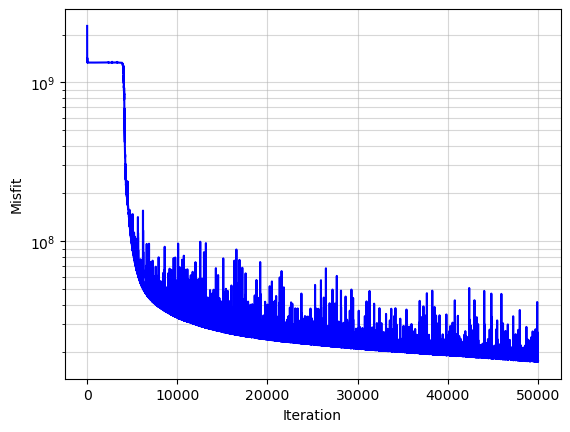

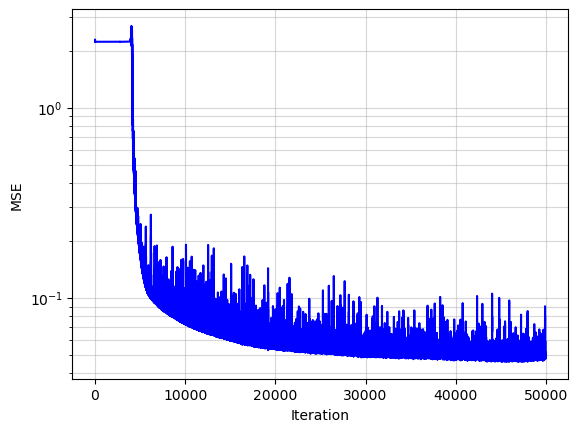

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.semilogy(misfit, color='b', linewidth=1.5)

plt.xlabel('Iteration')
plt.ylabel('Misfit')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

plt.figure()

plt.semilogy(misfit_mse, color='b', linewidth=1.5)

plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.grid(True, which="both", ls="-", alpha=0.5)

# 显示图像
plt.show()